In [111]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel,Field
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv
import os
load_dotenv()

True

In [112]:
llm1 = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",  # provider-backed
    task="text-generation",
    temperature=0.1,
)

llm2=HuggingFaceEndpoint(
    repo_id="MiniMaxAI/MiniMax-M2.7",
    task="text-generation",
    temperature=0.1,
)

llm3=HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.2-1B-Instruct",
    task="text-generation",
    temperature=0.1,
)

llm4=HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-R1",
    task="text-generation",
    temperature=0.2
)

LamaChat = ChatHuggingFace(llm=llm1)
MiniMaxChat=ChatHuggingFace(llm=llm2)
LammaSmall=ChatHuggingFace(llm=llm3)
DeepSeekChat=ChatHuggingFace(llm=llm4)

In [113]:
docs=(
    PyPDFLoader("docuements/Srijan_CV_2026.pdf").load() +
    PyPDFLoader("docuements/Chayandev_SDE_RESUME_2026.pdf").load()
)

In [114]:
chunks=RecursiveCharacterTextSplitter(chunk_size=850,chunk_overlap=150).split_documents(docs)

# for chunk in chunks:
#    print("Content:\n", chunk.page_content)
#    print("Metadata:", chunk.metadata)
#    print("=" * 50)

In [115]:
from sentence_transformers import SentenceTransformer
from langchain.embeddings.base import Embeddings
texts = [chunk.page_content for chunk in chunks]
class MiniLMEmbeddings(Embeddings):
    def __init__(self):
        from sentence_transformers import SentenceTransformer
        self.model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

    def embed_documents(self, texts):
        return self.model.encode(texts).tolist()

    def embed_query(self, text):
        return self.model.encode([text])[0].tolist()

emb = MiniLMEmbeddings()
vector_store=FAISS.from_documents(chunks, emb) # need embedding model not the vector


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 16074.32it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [116]:
retriever =vector_store.as_retriever(search_kwargs={"k":5})

In [117]:
UPPER_THRESHOLD=0.7
LOWER_THRESHOLD=0.3

In [118]:
class State(TypedDict):
    question:str
    docs:list[Document]

    good_docs:list[Document] # after filtering the retrieved docs based on the question
    verdict:Literal["CORRECT","INCORRECT","AMBIGUOUS"] # after filtering the retrieved docs based on the question
    reason:str # reason for the verdict
    
    strips:list[str] # sentence level strips of the context
    kept_strips:list[str] # after filtering the strips based on the question
    refined_context:str # after refining the context based on the question and filtering the strips

    web_docs:list[Document] # after web search based on the question
    web_query:str # query used for web search
    answer:str

In [119]:
def retrive(state:State):
    question=state['question']
    docs=retriever.invoke(question)
    return {"docs":docs}

In [120]:
# -----------------------
# Score - based doc evalutor
#----------------------------

class DocEvalScore(BaseModel):
    score:float=Field(description="Score between 0 and 1 indicating the relevance of the document to the question")
    reason:str=Field(description="Reason for the verdict")

doc_eval_prompt=ChatPromptTemplate.from_messages([
    ("system","You are a strict retrival evalutor for RAG.\n"
     "You will be given one retrived chunk and a question.\n"
     "Also return a reason for the score you give."
     "Output the score and reason in the following JSON format:{format_instructions}\n"
     ),  
    ("human","Question: {question}\n\nDocument Content: {doc_content}\n\nProvide a score and reason for the relevance of the document to the question.")
])    

doc_eval_output_parser=PydanticOutputParser(pydantic_object=DocEvalScore)
doc_eval_chain=doc_eval_prompt|MiniMaxChat| doc_eval_output_parser

def evaluate_doc(state:State):
    question=state['question']
    
    scores:list[float]=[]
    reasons:list[str]=[]
    good_docs:list[str]=[]

    for doc in state['docs']:
        doc_content=doc.page_content+"\n\n"+str(doc.metadata['source'])
        # print("Evaluating doc:", doc_content)
        response=doc_eval_chain.invoke({"question":question,"doc_content":doc_content,"format_instructions":doc_eval_output_parser.get_format_instructions()})
        scores.append(response.score)
        reasons.append(response.reason)
        if response.score>=UPPER_THRESHOLD:
            good_docs.append(doc)
    print("Scores:", scores)
    if (len(scores)>0 and all(score<=LOWER_THRESHOLD for score in scores)):
        return{
            "good_docs":[],
            "verdict":"INCORRECT",
            "reason":"No relevant documents found"
        }
    if (len(good_docs)>0 and len(good_docs)<len(state['docs'])):
        return{
            "good_docs":good_docs,
            "verdict":"CORRECT",
            "reason":"At least one relevant document found"
        } 
    
    return{
        "good_docs":good_docs,  
        "verdict":"AMBIGUOUS",
        "reason":f"No documents scored > {UPPER_THRESHOLD} but all scored > {LOWER_THRESHOLD}"
    }    

In [121]:
# Sentence level decomposition and filtering can be done using the LLM as well. For simplicity, we are skipping that step here.

from huggingface_hub import InferenceClient
from dotenv import load_dotenv
import re
load_dotenv()

def decomponse_to_sentences(text:str)->list[str]:
    text=re.sub(r'\s+', ' ', text).strip() # replace newlines with space
    sentences=re.split(r'(?<=[.!?])\s +', text)
    return [s.strip() for s in sentences if len(s.strip())>30]

class KeepOrDrop(BaseModel):
    decision:Literal["keep","drop"]=Field(description="Whether to keep or drop the sentence")

parser = PydanticOutputParser(pydantic_object=KeepOrDrop)
instructions = parser.get_format_instructions()

filter_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a strict relevance filer.\n"
     "Return keep if the sentence directly helps answer the question else drop .\n"
     "Use ONLY the JSON format mentioned below and nothing else\n"
     "Format_Instructions:{format_instructions}"), 
    ("human", "Question: {question}\n\nContext sentence: {sentence}\n\nShould we keep or drop this sentence for answering the question? Return only keep or drop")
])

filter_chain=filter_prompt | LamaChat | parser

def refine(state:State):
    question=state['question']

    if(state['verdict']=="CORRECT"):
        context="\n\n".join(d.page_content for d in state['good_docs']).strip()
    elif(state['verdict']=="INCORRECT"):
        context="\n\n".join(d.page_content for d in state['web_docs']).strip()  
    else:
            context="\n\n".join(d.page_content for d in state['good_docs']+state['web_docs']).strip()  

    strips=decomponse_to_sentences(context)

    kept_strips:list[str]=[]

    for strip in strips:
        result=filter_chain.invoke({"question":question,"sentence":strip,"format_instructions":instructions})
        if result.decision=="keep":
            kept_strips.append(strip)

    refined_context="\n".join(kept_strips).strip()
    return {"strips":strips,"kept_strips":kept_strips,"refined_context":refined_context}  

In [130]:
class WebSearchQuery(BaseModel):
    query:str=Field(description="Query to be used for web search")

rewrite_prompt=ChatPromptTemplate.from_messages([
    ("system","You are a helpful assistant for rewriting user queries for web search. Rewrite the question in a way that it can be directly used as a query for web search. Be concise and specific.\n"
    "Output the query in the following JSON format:{format_instructions}"),
    ("human","Question: {question}\n\nRewrite this question as a concise and specific query for web search.")
])
parser=PydanticOutputParser(pydantic_object=WebSearchQuery)
rewrite_chain=rewrite_prompt|LamaChat|parser


def rewrite_query(state:State):
    question=state['question']
    response=rewrite_chain.invoke({"question":question,"format_instructions":parser.get_format_instructions()})
    print("Web search query:", response.query)
    return {"web_query":response.query}

In [131]:
#----------------------------
# Web search tool
#----------------------------
tavily=TavilySearchResults(max_results=5)
def web_search(state:State):
    query=state.get("web_query") or state.get("question"," ")
    results=tavily.invoke({"query":query}) 

    web_docs=[]

    for result in results:
        title=result.get("title","")
        url=result.get("url","")
        content=result.get("content","") or result.get("snippet","")

        text=f"Title: {title}\nURL: {url}\nContent: {content}"
        web_docs.append(Document(page_content=text,metadata={"source":url,"title":title}))

    return {"web_docs":web_docs}    


In [132]:
def generate(state:State):
    question=state['question']
    docs=state['docs']
    context="\n".join([doc.page_content for doc in docs])
    prompt=ChatPromptTemplate.from_messages([
        ("system","You are a helpful assistant for answering questions based on the provided context.If not in the context, say you don't know."),
        ("human","Answer the question based on the following context:\n\nContext:\n{context}\n\nQuestion:{question}\nAnswer:")
    ])
    response=(prompt|LamaChat).invoke({"context":context,"question":question})
    return {"answer":response.content}

In [134]:
def route_after_evalution(state:State):
    if state['verdict']=="CORRECT":
        return "refine"
    else:
        return "web_search"

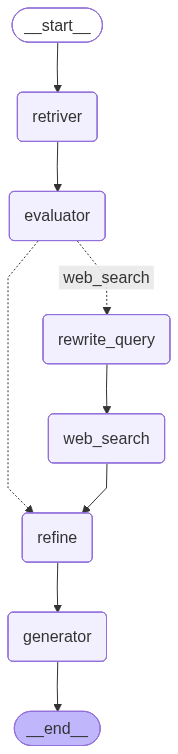

In [135]:
graph=StateGraph(State)
graph.add_node("retriver",retrive)
graph.add_node("evaluator",evaluate_doc)
graph.add_node("refine",refine)
graph.add_node("generator",generate)
graph.add_node("rewrite_query",rewrite_query)
graph.add_node("web_search",web_search)

graph.add_edge(START,"retriver")
graph.add_edge("retriver","evaluator")
graph.add_conditional_edges("evaluator",route_after_evalution,{"refine":"refine","web_search":"rewrite_query"})
graph.add_edge("rewrite_query","web_search")
graph.add_edge("web_search","refine")
graph.add_edge("refine","generator")
graph.add_edge("generator",END)

graph.compile()

In [ ]:
workflow=graph.compile()
result=workflow.invoke({"question":"Is Chayandev is an engineer?"})
from pprint import pprint

pprint(result['answer'])
pprint(result['verdict'])
pprint(result['reason'])
pprint(result['good_docs'])


HfHubHTTPError: Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Request ID: Root=1-69dd1f09-2997e3c57bc1b3894e658ae9;678c5656-232b-4e48-9f8a-706c558493d6)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.